# Exploratory Chess Analytics

This notebook explores personal chess performance data collected from Chess.com.

Main objectives:
- identify performance patterns
- analyze rating progression
- compare white vs black performance
- evaluate opening effectiveness
- explore behavioral trends

## Imports

In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt, matplotlib.dates as mdates
import sys
from pathlib import Path

## Load cleaned dataset

In [172]:
PROJECT_ROOT = Path().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import USERNAME

DATA_PATH = (
    PROJECT_ROOT
    / "dataset"
    / "processed"
    / USERNAME
    / f"{USERNAME}_games_clean.csv"
)

df = pd.read_csv(DATA_PATH)

df["date"] = pd.to_datetime(df["date"])

df.head()

,date,year,month,weekday,hour,side,time_class,time_control,player_rating,opponent_rating,rating_diff,result,player_result,opponent_result,score,opening,opponent,url
0,2020-11-10 15:30:24,2020,11,Tuesday,15,white,rapid,600,213,412,-199,loss,resigned,win,0.0,Polish Opening,TheMrNoName,https://www.chess.com/game/live/5719328865
1,2020-11-10 15:46:19,2020,11,Tuesday,15,black,rapid,600,345,216,129,win,win,resigned,1.0,Kings Pawn Opening Kings Knight Variation,smackersmashbot,https://www.chess.com/game/live/5719418873
2,2020-11-10 16:09:31,2020,11,Tuesday,16,black,rapid,600,256,371,-115,loss,checkmated,win,0.0,Kings Pawn Opening Leonardis Variation,amkh98,https://www.chess.com/game/live/5719482469
3,2020-11-10 17:39:54,2020,11,Tuesday,17,white,rapid,600,193,330,-137,loss,checkmated,win,0.0,Vienna Game Max Lange Defense,callumfindlay4,https://www.chess.com/game/live/5720005454
4,2020-11-10 17:51:42,2020,11,Tuesday,17,black,rapid,600,277,291,-14,win,win,resigned,1.0,Caro Kann Defense,callumfindlay4,https://www.chess.com/game/live/5720050101


## Dataset overview

In [173]:
df.shape

(21005, 18)

In [174]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21005 entries, 0 to 21004
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             21005 non-null  datetime64[ns]
 1   year             21005 non-null  int64         
 2   month            21005 non-null  int64         
 3   weekday          21005 non-null  object        
 4   hour             21005 non-null  int64         
 5   side             21005 non-null  object        
 6   time_class       21005 non-null  object        
 7   time_control     21005 non-null  object        
 8   player_rating    21005 non-null  int64         
 9   opponent_rating  21005 non-null  int64         
 10  rating_diff      21005 non-null  int64         
 11  result           21005 non-null  object        
 12  player_result    21005 non-null  object        
 13  opponent_result  21005 non-null  object        
 14  score            21005 non-null  float

In [175]:
df.describe(include="all")

,date,year,month,weekday,hour,side,time_class,time_control,player_rating,opponent_rating,rating_diff,result,player_result,opponent_result,score,opening,opponent,url
count,21005,21005.000000,21005.000000,21005,21005.000000,21005,21005,21005,21005.000000,21005.000000,21005.000000,21005,21005,21005,21005.000000,21005,21005,21005
unique,NaN,NaN,NaN,7,NaN,2,4,11,NaN,NaN,NaN,3,10,10,NaN,435,20240,21005
top,NaN,NaN,NaN,Monday,NaN,black,blitz,180,NaN,NaN,NaN,win,win,win,NaN,Four Knights Game Scotch Variation Accepted,ElettricRunner,https://www.chess.com/game/live/5719328865
freq,NaN,NaN,NaN,3264,NaN,10518,19823,15800,NaN,NaN,NaN,10181,10181,10156,NaN,1127,33,1
mean,2024-06-02 23:32:01.198048,2023.946679,6.200286,NaN,15.218710,NaN,NaN,NaN,627.965960,628.124589,-0.158629,NaN,NaN,NaN,0.500595,NaN,NaN,NaN
min,2020-11-10 15:30:24,2020.000000,1.000000,NaN,0.000000,NaN,NaN,NaN,100.000000,100.000000,-821.000000,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
25%,2023-09-05 18:10:30,2023.000000,3.000000,NaN,12.000000,NaN,NaN,NaN,559.000000,563.000000,-21.000000,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
50%,2024-10-26 22:26:20,2024.000000,6.000000,NaN,16.000000,NaN,NaN,NaN,649.000000,649.000000,-1.000000,NaN,NaN,NaN,0.500000,NaN,NaN,NaN
75%,2025-06-18 13:02:49,2025.000000,9.000000,NaN,20.000000,NaN,NaN,NaN,710.000000,711.000000,20.000000,NaN,NaN,NaN,1.000000,NaN,NaN,NaN
max,2026-05-07 12:00:24,2026.000000,12.000000,NaN,23.000000,NaN,NaN,NaN,1041.000000,1607.000000,597.000000,NaN,NaN,NaN,1.000000,NaN,NaN,NaN


## Time formats distribution

### Time Class

How the time format is called

In [176]:
df["time_class"].value_counts()

time_class
blitz     19823
rapid       653
bullet      455
daily        74
Name: count, dtype: int64

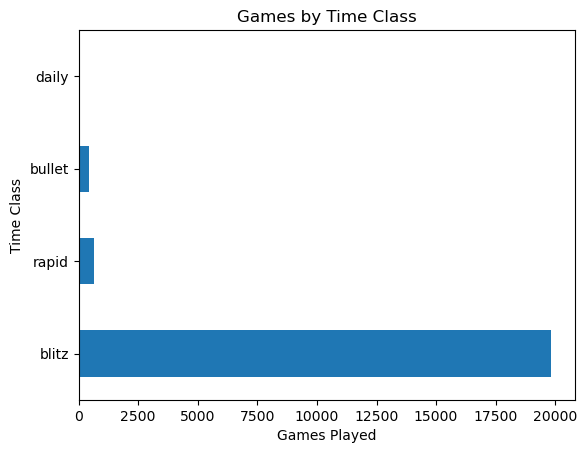

In [177]:
df["time_class"].value_counts().plot(
    kind="barh"
)

plt.title("Games by Time Class")
plt.xlabel("Games Played")
plt.ylabel("Time Class")

plt.show()

### Time control

Total amount of time a player has in a single game

In [178]:
df["time_control"].value_counts()

time_control
180          15800
300           3745
600            648
60             455
180+2          278
1/86400         42
1/259200        18
1/604800        10
1/1209600        4
1800             3
3600             2
Name: count, dtype: int64

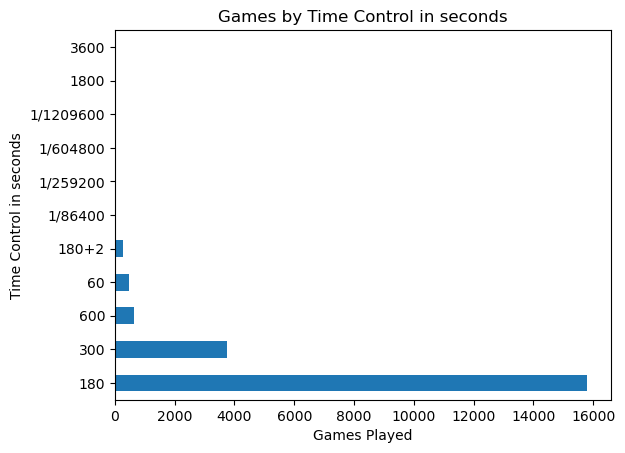

In [179]:
df["time_control"].value_counts().plot(
    kind="barh"
)

plt.title("Games by Time Control in seconds")
plt.xlabel("Games Played")
plt.ylabel("Time Control in seconds")

plt.show()

## Rating progression on short formats

We will take into considerations the shortest time classes: rapid, bullet and blitz (the most popular)

### Rapid - 10 minutes per game



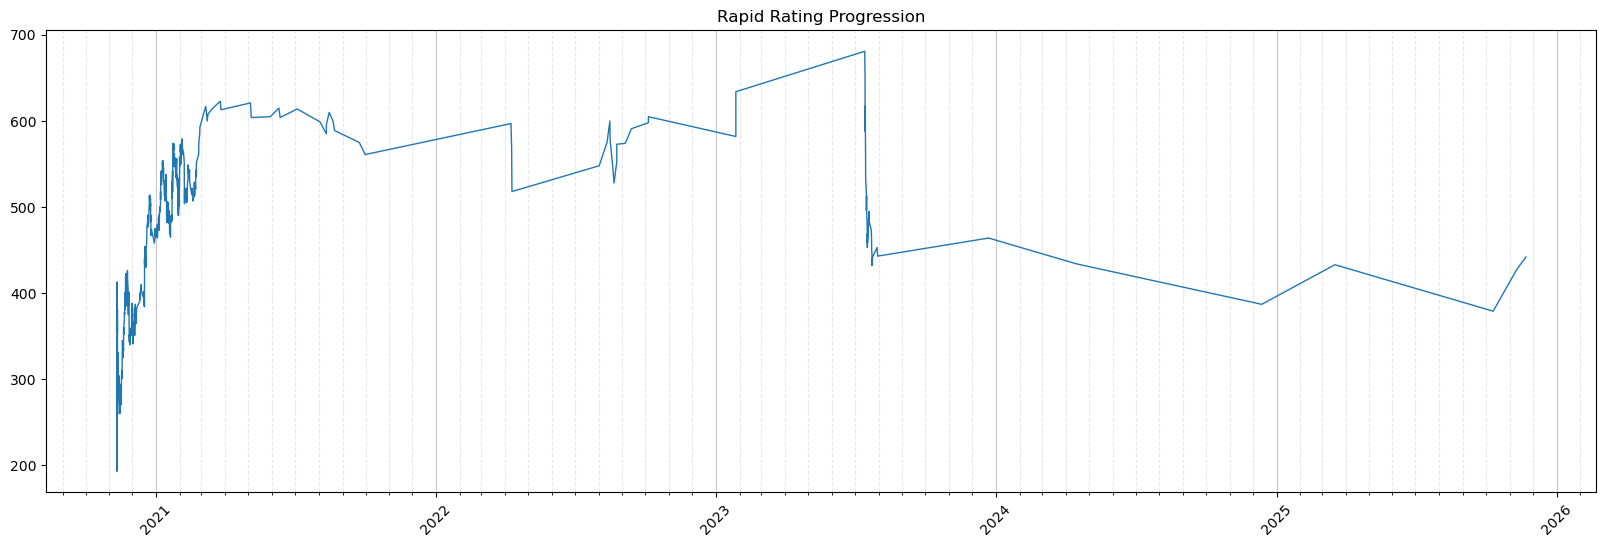

In [180]:
rapid = df[
    df["time_class"] == "rapid"
].sort_values("date")

plt.figure(figsize=(20,6))
ax = plt.gca() # Ottieni gli assi correnti

plt.plot(rapid["date"], rapid["player_rating"], linewidth=1)

# --- CONFIGURAZIONE DATE ---

# 1. Imposta una tacca principale per ogni inizio anno (es. 2023, 2024)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # Mostra solo l'anno

# 2. Imposta tacche secondarie per ogni mese
ax.xaxis.set_minor_locator(mdates.MonthLocator())
# Opzionale: mostra il formato "Mese Anno" (es. Jan 2023) 
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# 3. Aggiungi una griglia per i mesi (linee leggere)
plt.grid(True, which='minor', axis='x', linestyle='--', alpha=0.3)
plt.grid(True, which='major', axis='x', linestyle='-', alpha=0.7)

# Ruota le date per evitare sovrapposizioni
plt.xticks(rotation=45)

plt.title("Rapid Rating Progression")
plt.show()

### Bullet - 1 minute per game

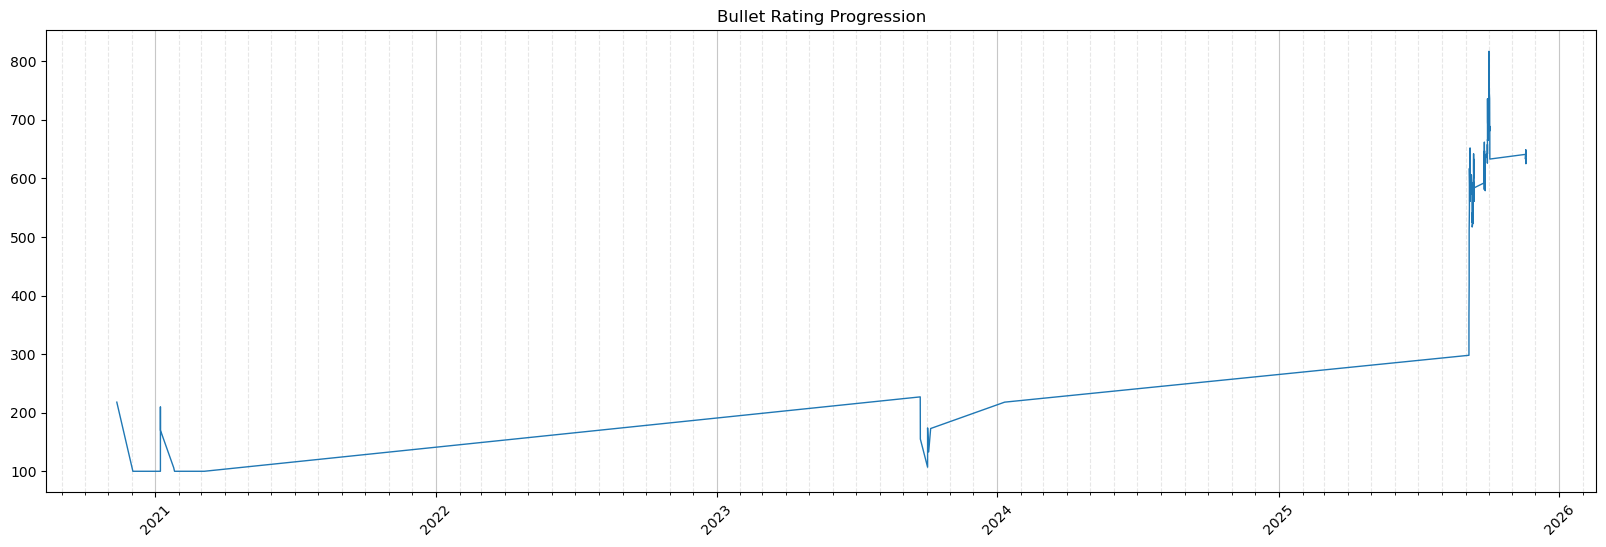

In [181]:
bullet = df[
    df["time_class"] == "bullet"
].sort_values("date")

plt.figure(figsize=(20,6))
ax = plt.gca() # Ottieni gli assi correnti

plt.plot(bullet["date"], bullet["player_rating"], linewidth=1)

# --- CONFIGURAZIONE DATE ---

# 1. Imposta una tacca principale per ogni inizio anno (es. 2023, 2024)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # Mostra solo l'anno

# 2. Imposta tacche secondarie per ogni mese
ax.xaxis.set_minor_locator(mdates.MonthLocator())
# Opzionale: mostra il formato "Mese Anno" (es. Jan 2023) 
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# 3. Aggiungi una griglia per i mesi (linee leggere)
plt.grid(True, which='minor', axis='x', linestyle='--', alpha=0.3)
plt.grid(True, which='major', axis='x', linestyle='-', alpha=0.7)

# Ruota le date per evitare sovrapposizioni
plt.xticks(rotation=45)

plt.title("Bullet Rating Progression")
plt.show()

### Blitz - 3 or 5 minutes per game 

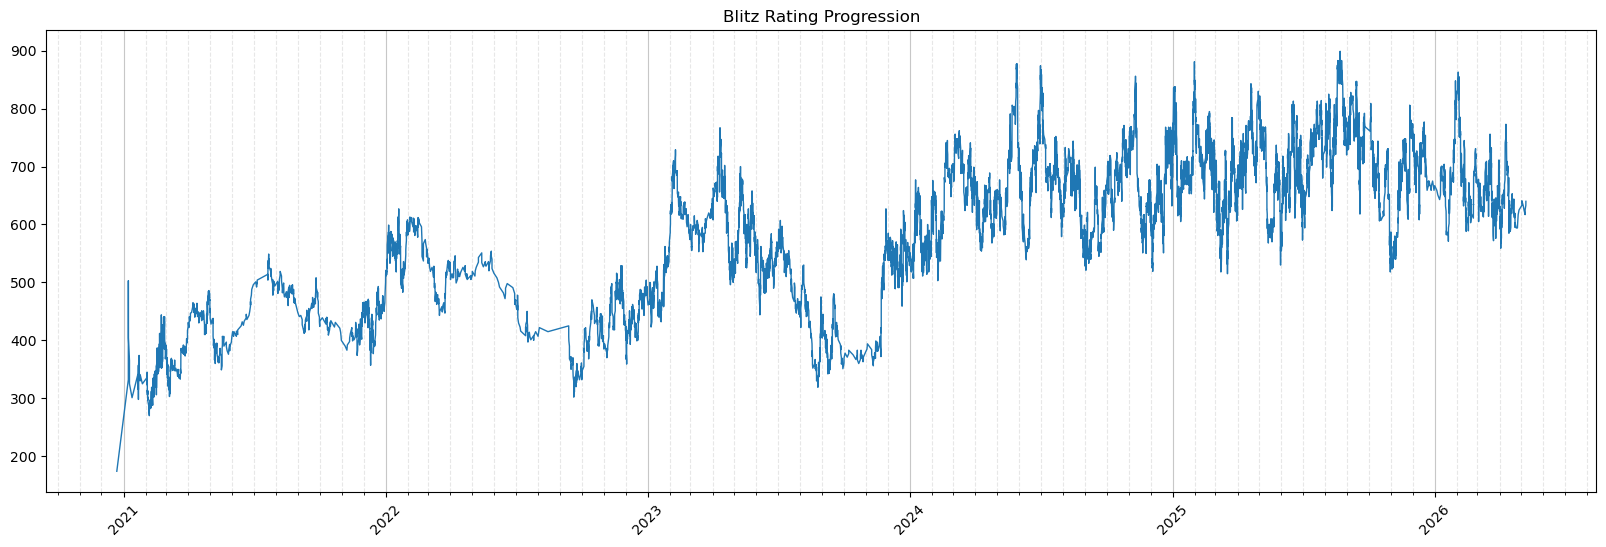

In [182]:
blitz = df[
    df["time_class"] == "blitz"
].sort_values("date")

plt.figure(figsize=(20,6))
ax = plt.gca() # Ottieni gli assi correnti

plt.plot(blitz["date"], blitz["player_rating"], linewidth=1)

# --- CONFIGURAZIONE DATE ---

# 1. Imposta una tacca principale per ogni inizio anno (es. 2023, 2024)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # Mostra solo l'anno

# 2. Imposta tacche secondarie per ogni mese
ax.xaxis.set_minor_locator(mdates.MonthLocator())
# Opzionale: mostra il formato "Mese Anno" (es. Jan 2023) 
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# 3. Aggiungi una griglia per i mesi (linee leggere)
plt.grid(True, which='minor', axis='x', linestyle='--', alpha=0.3)
plt.grid(True, which='major', axis='x', linestyle='-', alpha=0.7)

# Ruota le date per evitare sovrapposizioni
plt.xticks(rotation=45)

plt.title("Blitz Rating Progression")
plt.show()

### Plot of Rating progression for all major Time Classes

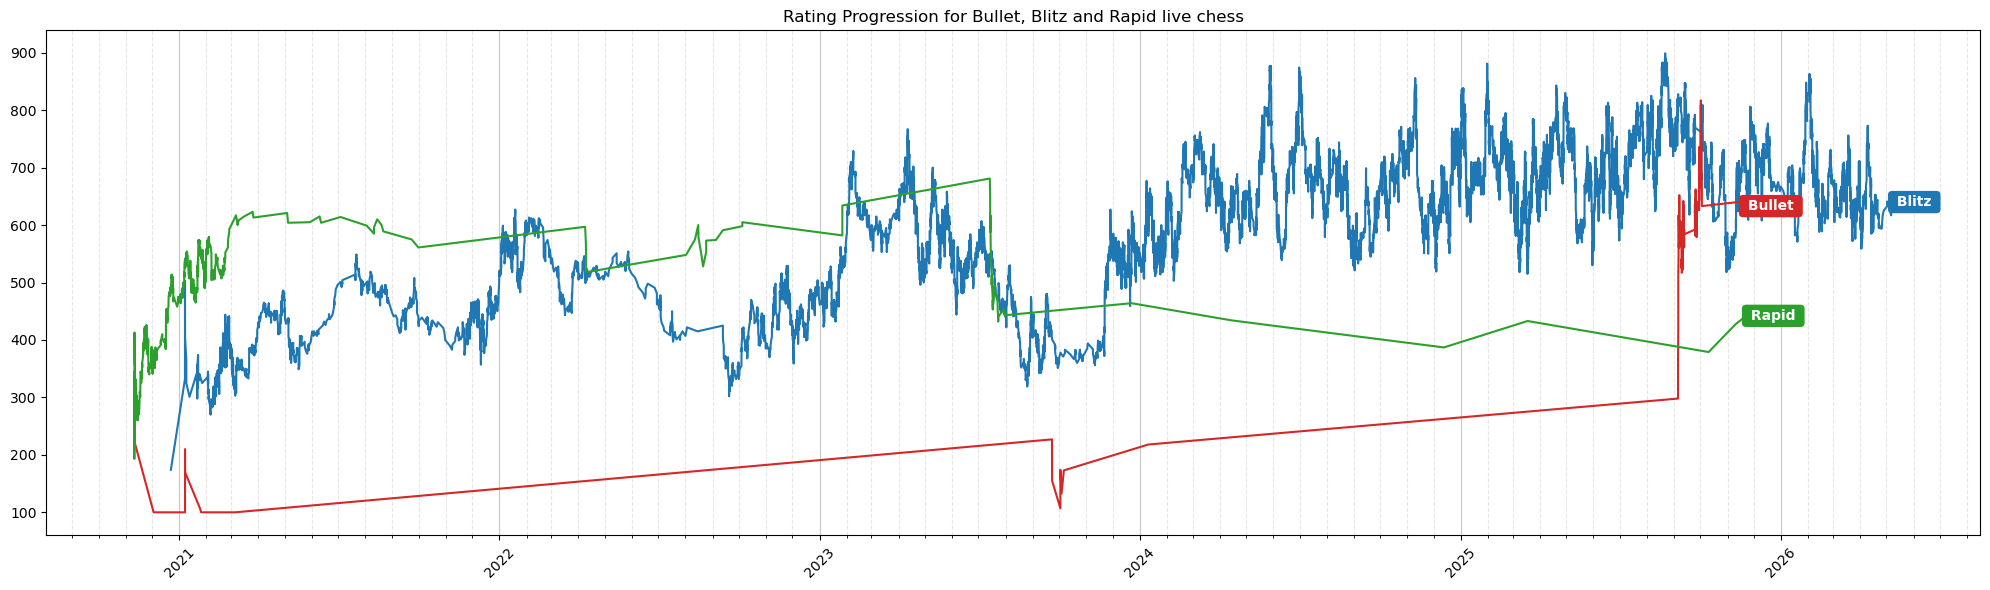

In [183]:
plt.figure(figsize=(20, 6))
ax = plt.gca()

# 1. Definiamo i colori personalizzati
colori = {
    "blitz": "#1f77b4",  # Blu
    "bullet": "#d62728", # Rosso
    "rapid": "#2ca02c"   # Verde
}

# --- PLOT DELLE LINEE ---
plt.plot(blitz["date"], blitz["player_rating"], color=colori["blitz"], linewidth=1.5)
plt.plot(bullet["date"], bullet["player_rating"], color=colori["bullet"], linewidth=1.5)
plt.plot(rapid["date"], rapid["player_rating"], color=colori["rapid"], linewidth=1.5)

# --- CONFIGURAZIONE DATE E GRIGLIA ---
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
plt.grid(True, which='minor', axis='x', linestyle='--', alpha=0.3)
plt.grid(True, which='major', axis='x', linestyle='-', alpha=0.7)
plt.xticks(rotation=45)

# --- FUNZIONE PER AGGIUNGERE LABEL COLORATE ---
def add_label(df, label_text, color):
    last_date = df["date"].iloc[-1]
    last_rating = df["player_rating"].iloc[-1]
    
    plt.text(
        last_date, last_rating, f' {label_text} ', 
        color='white',            # Colore del testo
        fontweight='bold', 
        va='center',
        bbox=dict(
            facecolor=color,      # Colore di sfondo uguale alla linea
            edgecolor='none',     # Rimuove il bordo del rettangolo
            boxstyle='round,pad=0.3' # Arrotonda i bordi e aggiunge spaziatura
        )
    )

# 2. Applichiamo le label
add_label(blitz, "Blitz", colori["blitz"])
add_label(bullet, "Bullet", colori["bullet"])
add_label(rapid, "Rapid", colori["rapid"])

plt.title("Rating Progression for Bullet, Blitz and Rapid live chess")

# Aggiunge un po' di spazio a destra per non far uscire le label dal grafico
plt.tight_layout() 
plt.show()


## White vs Black analysis

In [184]:
df.groupby("side")["score"].mean()

side
black    0.477182
white    0.524077
Name: score, dtype: float64

In [185]:
white_black = (
    df.groupby("side")
    .agg({
        "score": "mean",
        "player_rating": "mean"
    })
)

white_black

,score,player_rating
side,,
black,0.477182,627.754611
white,0.524077,628.177935


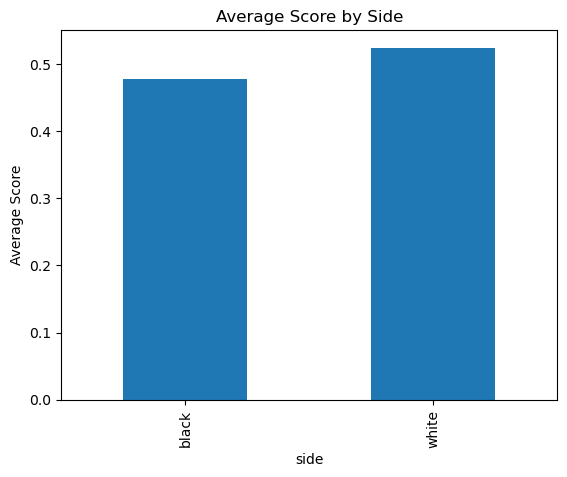

In [186]:
white_black["score"].plot(
    kind="bar"
)

plt.title("Average Score by Side")
plt.ylabel("Average Score")

plt.show()

## Performance by hour

### Games count

In [187]:
df["hour"].value_counts().sort_index()

hour
0      787
1      304
2      119
3       51
4       12
5        5
6        9
7      117
8     1043
9      656
10     868
11    1158
12    1349
13     985
14    1387
15    1414
16    1189
17    1037
18    1241
19    1003
20    1522
21    1614
22    1746
23    1389
Name: count, dtype: int64

### Winrate by hour

In [188]:
hourly = (
    df.groupby("hour")
    .agg({
        "score": "mean",
        "url": "count"
    })
    .rename(columns={
        "url": "games"
    })
)

hourly

,score,games
hour,,
0,0.522872,787
1,0.481908,304
2,0.462185,119
3,0.450980,51
4,0.500000,12
5,0.600000,5
6,0.111111,9
7,0.517094,117
8,0.477948,1043


### Plot

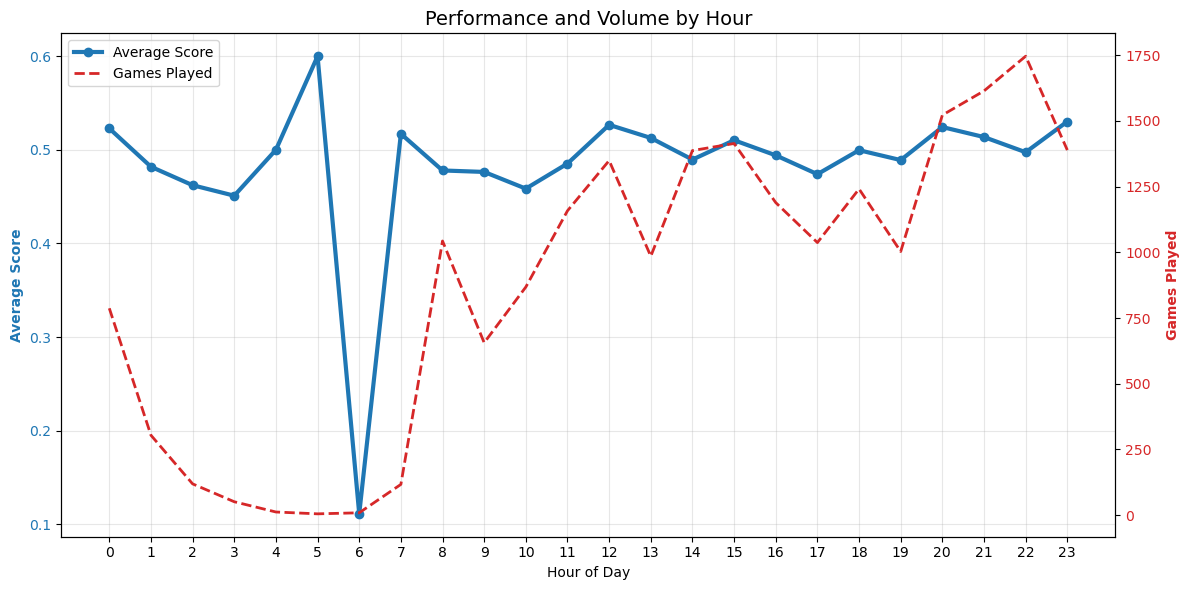

In [189]:
plt.figure(figsize=(12, 6))

# --- PRIMA SERIE: Score (Asse Y Sinistro) ---
ax1 = plt.gca() # Ottieni l'asse corrente
ax1.plot(
    hourly.index,
    hourly["score"],
    color="tab:blue",
    linewidth=3,
    label="Average Score",
    marker='o' # Aggiunge dei punti per ogni ora
)
ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Average Score", color="tab:blue", fontweight="bold")
ax1.tick_params(axis='y', labelcolor="tab:blue")
ax1.set_xticks(range(24))

# --- SECONDA SERIE: Games (Asse Y Destro) ---
ax2 = ax1.twinx() # Crea un secondo asse che condivide l'asse X
ax2.plot(
    hourly.index,
    hourly["games"],
    color="tab:red",
    linewidth=2,
    linestyle="--", # Linea tratteggiata per distinguerla
    label="Games Played"
)
ax2.set_ylabel("Games Played", color="tab:red", fontweight="bold")
ax2.tick_params(axis='y', labelcolor="tab:red")

# --- TITOLO E GRIGLIA ---
plt.title("Performance and Volume by Hour", fontsize=14)
ax1.grid(True, alpha=0.3) # Griglia leggera basata sull'asse principale

# Opzionale: Unire le legende di entrambi gli assi
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()


## Opening analysis

### Minimum games filter

We are looking at openings that have been used at least 500 times

In [190]:
opening_stats = (
    df.groupby(["opening","side"])
    .agg({
        "score": "mean",
        "url": "count"
    })
    .rename(columns={
        "url": "games"
    }) .sort_values(by="score", ascending=False)
)

opening_stats = opening_stats[
    opening_stats["games"] >= 500
]

### Most Used Openings

In [191]:
opening_stats.sort_values(
    "games",
    ascending=False
).reset_index().head(10)

,opening,side,score,games
0,Vienna Game,white,0.608178,966
1,Kings Pawn Opening,black,0.572347,933
2,Four Knights Game Scotch Variation Accepted,white,0.528495,930
3,Three Knights Opening,white,0.535834,893
4,Scandinavian Defense Closed,white,0.432555,771
5,Petrovs Defense Three Knights Game,white,0.533835,532


### Best openings

In [192]:
opening_stats.sort_values(
    "score",
    ascending=False
).reset_index().head(10)

,opening,side,score,games
0,Vienna Game,white,0.608178,966
1,Kings Pawn Opening,black,0.572347,933
2,Three Knights Opening,white,0.535834,893
3,Petrovs Defense Three Knights Game,white,0.533835,532
4,Four Knights Game Scotch Variation Accepted,white,0.528495,930
5,Scandinavian Defense Closed,white,0.432555,771


## Rating difference analysis

How do I perform against better rated opponents?

### Bucket ratings

In [193]:
df["rating_bucket"] = pd.cut(
    df["rating_diff"],
    bins=[
        -1000,
        -300,
        -100,
        100,
        300,
        1000
    ]
)

### Performance

In [194]:
rating_perf = (
    df.groupby(["rating_bucket"], observed=False)
    ["score"]
    .mean()
)

rating_perf

rating_bucket
(-1000, -300]    0.111111
(-300, -100]     0.119617
(-100, 100]      0.499172
(100, 300]       0.935685
(300, 1000]      1.000000
Name: score, dtype: float64

### Plot

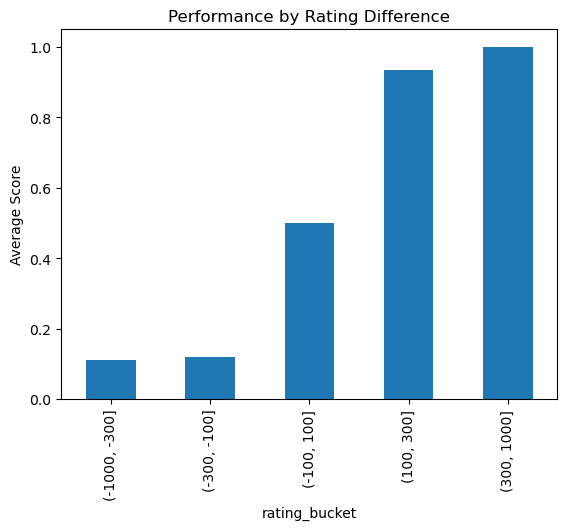

In [195]:
rating_perf.plot(kind="bar")

plt.title(
    "Performance by Rating Difference"
)

plt.ylabel("Average Score")

plt.show()

## How I win, lose or draw

### Data Prep

In [196]:
wins = df[df['result'] == 'win' ]
draws = df[df['result'] == 'draw' ]
losses = df[df['result'] == 'loss' ]

In [197]:
wins_perc = wins.groupby(['opponent_result'])['result'].count().reset_index(name='count')

wins_perc['percentage'] = round((wins_perc['count'] / wins_perc['count'].sum()) * 100,2)

draws_perc = draws.groupby(['opponent_result'])['result'].count().reset_index(name='count')

draws_perc['percentage'] = round((draws_perc['count'] / draws_perc['count'].sum()) * 100,2)

losses_perc = losses.groupby(['player_result'])['result'].count().reset_index(name='count')

losses_perc['percentage'] = round((losses_perc['count'] / losses_perc['count'].sum()) * 100,2)


### Plot

In [198]:
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99',"#a099ff"]

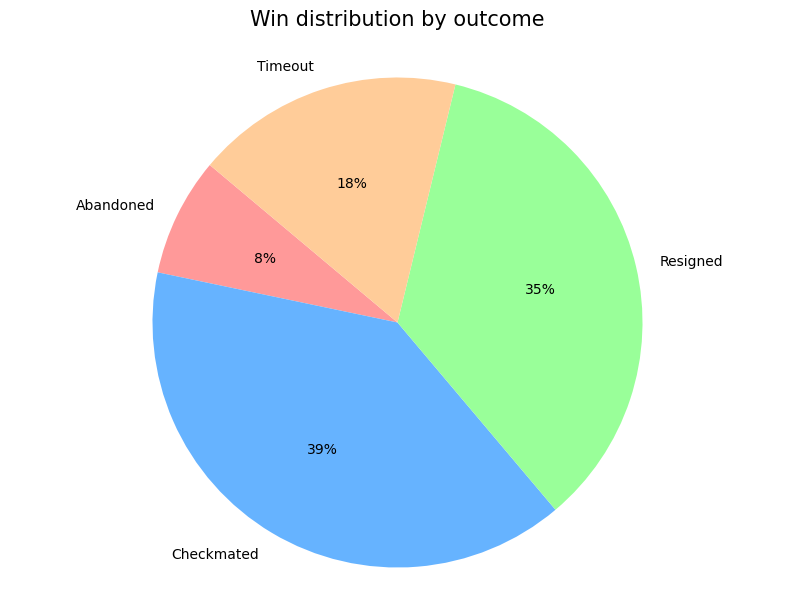

In [199]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.pie(
    wins_perc['count'], 
    labels=[n.title() for n in wins_perc['opponent_result']] , 
    autopct='%1.0f%%', # Mostra una cifra decimale
    startangle=140, 
    colors=colors, 
)

ax.set_title('Win distribution by outcome', fontsize=15, pad=20)

plt.axis('equal') 
plt.show()

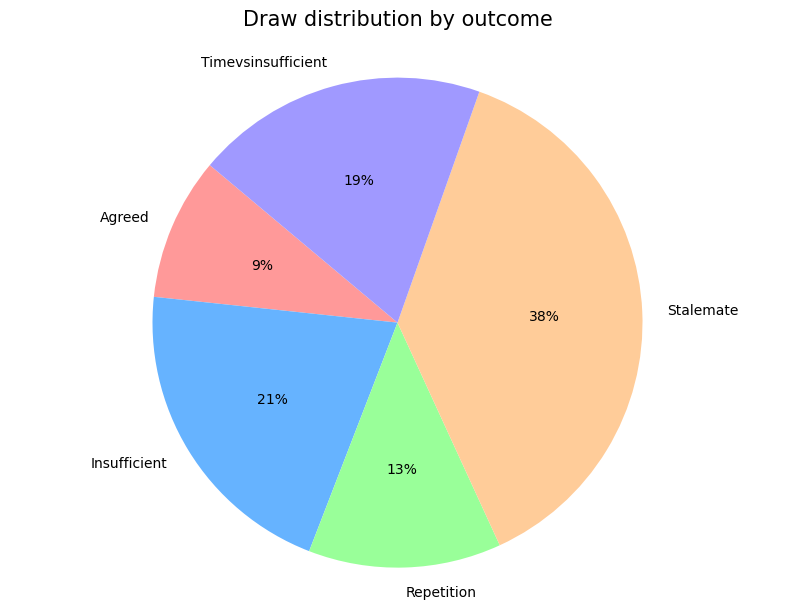

In [200]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.pie(
    draws_perc['count'], 
    labels=[n.title() for n in draws_perc['opponent_result']] , 
    autopct='%1.0f%%', # Mostra una cifra decimale
    startangle=140, 
    colors=colors, 
)

ax.set_title('Draw distribution by outcome', fontsize=15, pad=20)

plt.axis('equal') 
plt.show()

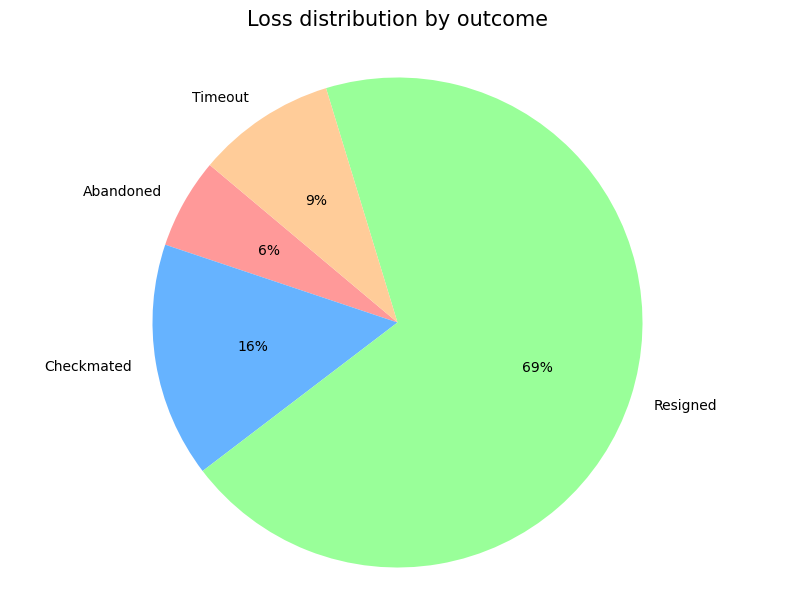

In [201]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.pie(
    losses_perc['count'], 
    labels=[n.title() for n in losses_perc['player_result']] , 
    autopct='%1.0f%%', # Mostra una cifra decimale
    startangle=140, 
    colors=colors, 
)

ax.set_title('Loss distribution by outcome', fontsize=15, pad=20)

plt.axis('equal') 
plt.show()

## Weekday performance

In [202]:
weekday_perf = (
    df.groupby("weekday")
    ["score"]
    .mean()
)

weekday_perf

weekday
Friday       0.507256
Monday       0.504902
Saturday     0.494857
Sunday       0.488493
Thursday     0.496376
Tuesday      0.513866
Wednesday    0.497994
Name: score, dtype: float64

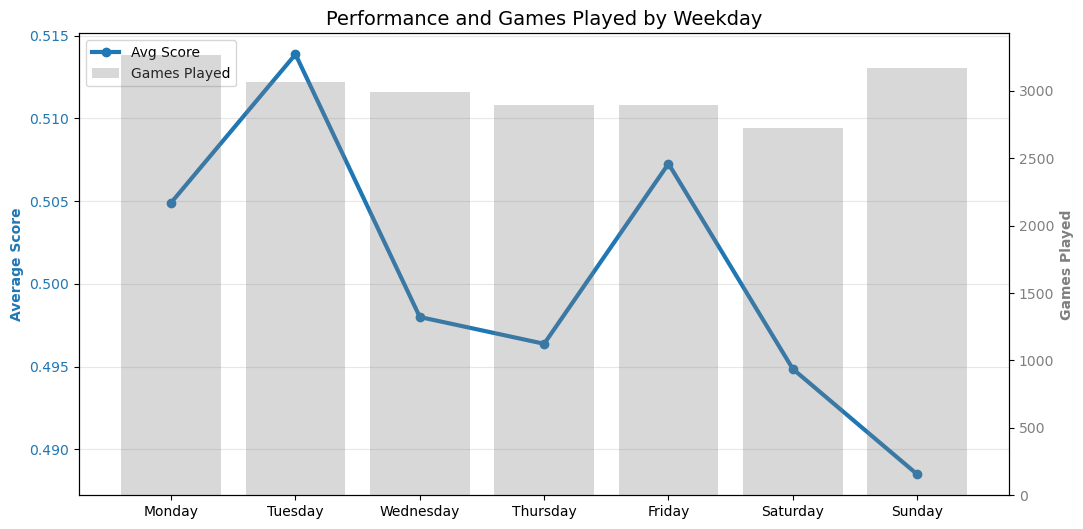

In [203]:
weekday_stats = (
    df.groupby("weekday")
    .agg({
        "score": "mean",
        "url": "count"
    })
    .rename(columns={"url": "games"})
)

days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

weekday_stats = weekday_stats.reindex(days_order)

plt.figure(figsize=(12, 6))

ax1 = plt.gca()
ax1.plot(weekday_stats.index, weekday_stats["score"], color="tab:blue", marker='o', linewidth=3, label="Avg Score")
ax1.set_ylabel("Average Score", color="tab:blue", fontweight="bold")
ax1.tick_params(axis='y', labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.bar(weekday_stats.index, weekday_stats["games"], color="tab:gray", alpha=0.3, label="Games Played")
ax2.set_ylabel("Games Played", color="tab:gray", fontweight="bold")
ax2.tick_params(axis='y', labelcolor="tab:gray")

plt.title("Performance and Games Played by Weekday", fontsize=14)
ax1.grid(True, axis='y', alpha=0.3)

lines, labels = ax1.get_legend_handles_labels()
bars, labels_b = ax2.get_legend_handles_labels()
ax1.legend(lines + bars, labels + labels_b, loc="upper left")

plt.show()


## Correlation analysis

In [204]:
numeric_cols = [
    "player_rating",
    "opponent_rating",
    "rating_diff",
    "score"
]

df[numeric_cols].corr()

,player_rating,opponent_rating,rating_diff,score
player_rating,1.000000,0.948382,0.043686,0.032585
opponent_rating,0.948382,1.000000,-0.275397,-0.126095
rating_diff,0.043686,-0.275397,1.000000,0.496007
score,0.032585,-0.126095,0.496007,1.000000


# Initial Findings

Some interesting early observations:

- Performance appears to vary significantly by hour of day
- Certain openings consistently outperform others
- White and Black performance differ noticeably
- Rating difference heavily impacts expected results

## Export Tables

In [205]:
EXPORT_DIR = (
    PROJECT_ROOT
    / "dataset"
    / "processed"
    / USERNAME
)

opening_stats.to_csv(
    EXPORT_DIR / "opening_stats.csv"
)

hourly.to_csv(
    EXPORT_DIR / "hourly_performance.csv"
)